In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Import the data


In [3]:
data = np.loadtxt(open("sample_data/mnist_train_small.csv", "rb"), delimiter=",", skiprows=1)

# we don't need the labels here
data = data[:, 1:]

# normalize the data to a range of [-1 1] (b/c tanh output)
dataNorm = data / np.max(data)
dataNorm = dataNorm * 2 - 1

dataT = torch.from_numpy(dataNorm).float().to(device)

batchsize = 200

## create the generator and discriminator


In [5]:
class discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256) # 28x28=784
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

dnet = discriminator().to(device)

In [6]:
# testing the model 
y = dnet(torch.randn(10, 784).to(device))

y

tensor([[0.5064],
        [0.5131],
        [0.5372],
        [0.5473],
        [0.5118],
        [0.4868],
        [0.5300],
        [0.5334],
        [0.4972],
        [0.5231]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [7]:
class generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256) # 64 is the starting size of the random noise vector
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 784)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x))
        x = F.leaky_relu(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        return x

gnet = generator().to(device)

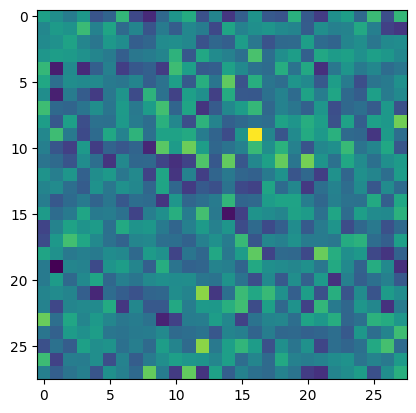

In [12]:
y = gnet(torch.randn(10, 64).to(device))

plt.imshow(y[0].detach().cpu().numpy().reshape(28, 28))
plt.show()

## training the model


In [14]:
loss = nn.BCELoss()

dnet = discriminator().to(device)
gnet = generator().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0003)
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0003)

In [18]:
numepochs = 50000

losses = np.zeros((numepochs, 2))
disdecs = np.zeros((numepochs, 2)) # discriminator decisions for real and fake data

for i in range(numepochs):
    # create mini matches of REAL and FAKE images
    randidx = torch.randint(dataT.shape[0], (batchsize,))
    realdata = dataT[randidx, :].to(device)
    fakedata = gnet(torch.randn(batchsize, 64).to(device))

    # labels used for real and fake data
    reallabels = torch.ones(batchsize, 1).to(device)
    fakelabels = torch.zeros(batchsize, 1).to(device)

    # TRAIN THE DISCRIMINATOR
    pred_real = dnet(realdata) # giving real data to discriminator and telling them that the all labels are 1
    d_loss_real = loss(pred_real, reallabels) # all labels are 1

    pred_fake = dnet(fakedata.detach()) # detach so that gradients don't flow to generator
    d_loss_fake = loss(pred_fake, fakelabels) # giving fake data to discriminator and telling them that the all labels are 0

    # combined loss
    d_loss = d_loss_real + d_loss_fake

    losses[i, 0] = d_loss.item()
    disdecs[i, 0] = torch.mean((pred_real > 0.5).float()).detach().cpu().numpy()

    # backprop and optimize
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # training the generator
    fakedata = gnet(torch.randn(batchsize, 64).to(device))
    pred_fake = dnet(fakedata)
    g_loss = loss(pred_fake, reallabels) # we are lying the discriminator that the fake data is real, so we use reallabels

    losses[i, 1] = g_loss.item()
    disdecs[i, 1] = torch.mean((pred_fake > 0.5).float()).detach().cpu().numpy()

    # backprop and optimize
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # print the status every 1000 epochs
    if i % 1000 == 0:
        print(f"Epoch {i}: D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}, D Real Acc: {disdecs[i, 0]:.4f}, D Fake Acc: {disdecs[i, 1]:.4f}")

Epoch 0: D Loss: 1.4297, G Loss: 0.6814, D Real Acc: 0.0150, D Fake Acc: 1.0000
Epoch 1000: D Loss: 3.5019, G Loss: 1.0123, D Real Acc: 0.5100, D Fake Acc: 0.3950
Epoch 2000: D Loss: 0.8007, G Loss: 2.1559, D Real Acc: 0.8200, D Fake Acc: 0.0100
Epoch 3000: D Loss: 1.9790, G Loss: 1.5749, D Real Acc: 0.6200, D Fake Acc: 0.1650
Epoch 4000: D Loss: 0.2374, G Loss: 2.7471, D Real Acc: 0.9850, D Fake Acc: 0.0000
Epoch 5000: D Loss: 1.1815, G Loss: 1.1479, D Real Acc: 0.7050, D Fake Acc: 0.0750
Epoch 6000: D Loss: 0.9713, G Loss: 2.2008, D Real Acc: 0.8150, D Fake Acc: 0.1100
Epoch 7000: D Loss: 0.5270, G Loss: 2.2901, D Real Acc: 0.8300, D Fake Acc: 0.0050
Epoch 8000: D Loss: 0.6931, G Loss: 3.8368, D Real Acc: 0.8400, D Fake Acc: 0.0000
Epoch 9000: D Loss: 0.7006, G Loss: 2.0566, D Real Acc: 0.8800, D Fake Acc: 0.0850
Epoch 10000: D Loss: 0.6681, G Loss: 2.2407, D Real Acc: 0.7850, D Fake Acc: 0.0400
Epoch 11000: D Loss: 0.8116, G Loss: 1.8238, D Real Acc: 0.8050, D Fake Acc: 0.1550
Epoch

## vizualize the losses


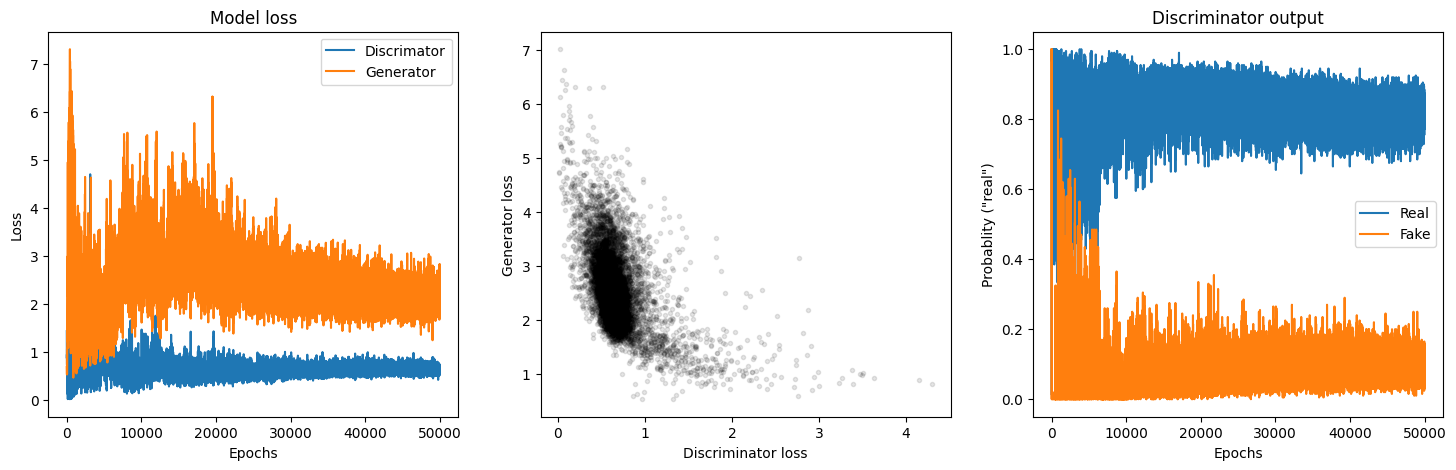

In [19]:
fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([4000,5000])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(disdecs)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()

## some fake digits (data)


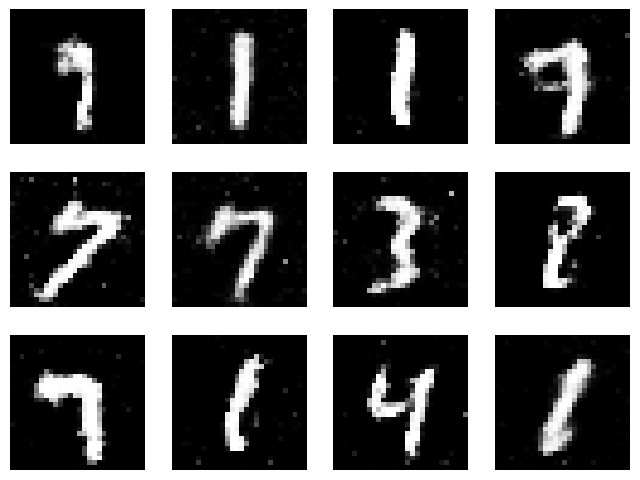

In [25]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()

# and visualize
fig,axs = plt.subplots(3,4,figsize=(8,6))
for i,ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i,:,].detach().view(28,28),cmap='gray')
  ax.axis('off')

plt.show()

### **_this is see which of them descriminator was fooled that they were real, technically all of them are fake_**


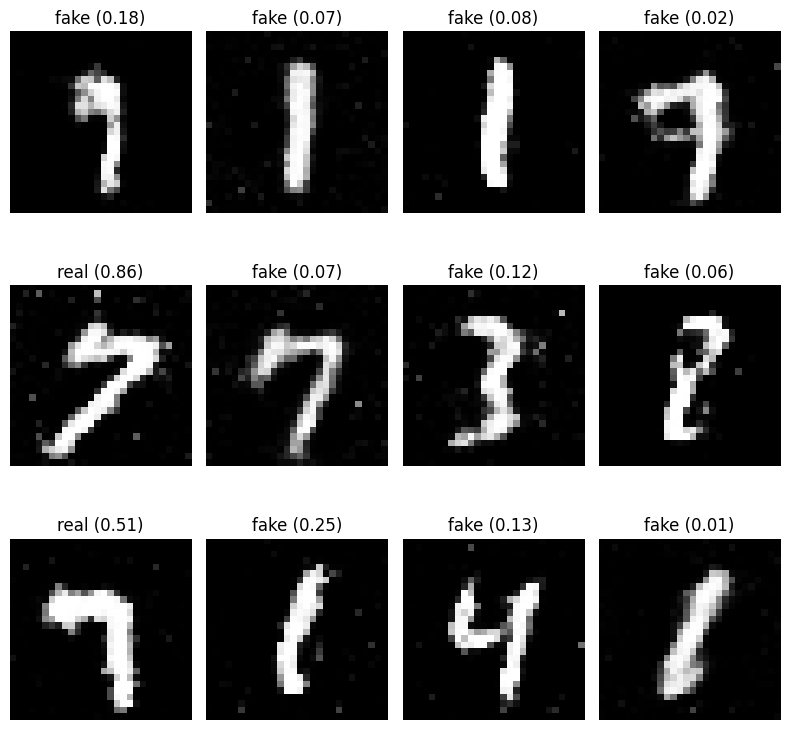

In [26]:
# put the discriminator in eval mode
dnet.eval()

# run the fake images through the discriminator
status = dnet(fake_data.to(device)).cpu()

# convert probabilities into real/fake labels (assuming sigmoid output, threshold 0.5)
labels = ['real' if s > 0.5 else 'fake' for s in status.detach().numpy().flatten()]

# visualize with discriminator's verdict as the title of each subplot
fig, axs = plt.subplots(3, 4, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
  ax.imshow(fake_data[i, :].detach().view(28, 28), cmap='gray')
  ax.set_title(f'{labels[i]} ({status[i].item():.2f})')
  ax.axis('off')

plt.tight_layout()
plt.show()